# Q6: ML Affordability Model — XGBoost Classifier
**CarIQ Capstone — Day 16 Bonus**

## Business Question
Can a machine learning model predict loan affordability more accurately
than the rule-based 40% EMI threshold — and which features matter most?

## Approach
- Model: XGBoost Gradient Boosted Classifier
- Features: income, credit score, employment type, price, tenure, rate, EMI
- Target: is_affordable (1 = affordable, 0 = not)
- Key improvement: probability score (0–1) instead of binary yes/no

In [1]:
import sys
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

sys.path.append('../src/ml')
from predict import predict_single, predict_batch, get_model_metrics

master = pd.read_csv('../data/master.csv')
loans  = master[master['payment_mode'] == 'Loan'].copy()
loans  = loans.dropna(subset=['emi_amount_usd','annual_income_usd'])

print(f"Loan transactions: {len(loans)}")
print(f"Affordable (rule): {loans['is_affordable'].sum()}")
metrics = get_model_metrics()
print(f"\nModel Accuracy : {metrics.get('accuracy', 'N/A')}")
print(f"ROC-AUC        : {metrics.get('roc_auc', 'N/A')}")
print(f"CV Accuracy    : {metrics.get('cv_mean_accuracy', 'N/A')}")

Loan transactions: 59
Affordable (rule): 36

Model Accuracy : 1.0
ROC-AUC        : 1.0
CV Accuracy    : 0.8649


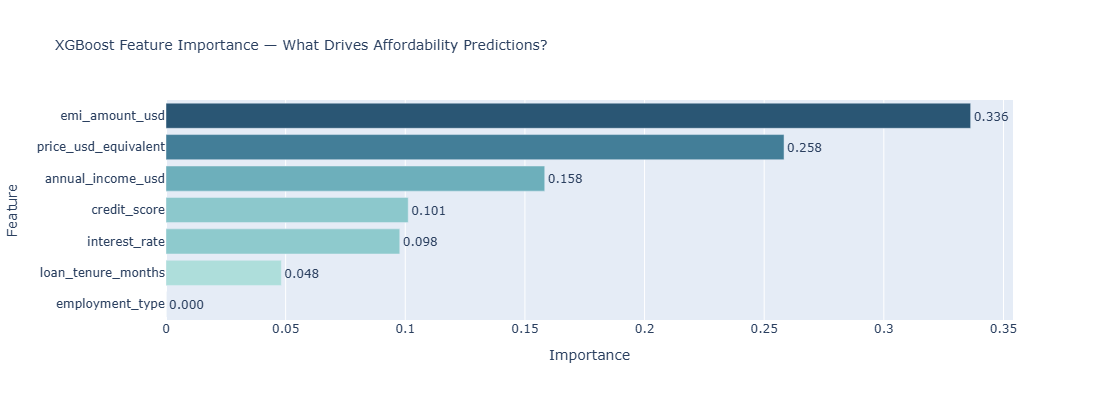

In [2]:
# Feature Importance Chart
fi    = metrics['feature_importance']
fi_df = pd.DataFrame(list(fi.items()), columns=['Feature','Importance'])
fi_df = fi_df.sort_values('Importance', ascending=True)

fig = px.bar(
    fi_df, x='Importance', y='Feature', orientation='h',
    color='Importance', color_continuous_scale='Teal',
    title='XGBoost Feature Importance — What Drives Affordability Predictions?',
    text='Importance'
)
fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.update_layout(height=400, coloraxis_showscale=False, title_font_size=14)
fig.show()

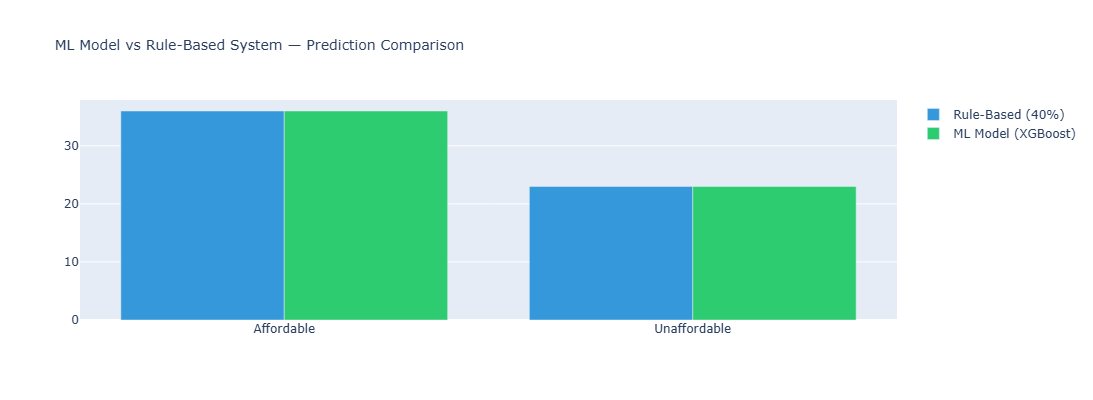

In [3]:
# Batch predict on all loans
loans_pred = predict_batch(loans.copy())

# ML vs Rule comparison
fig2 = go.Figure()
categories = ['Affordable', 'Unaffordable']
rule_counts = [loans['is_affordable'].sum(), (loans['is_affordable']==0).sum()]
ml_counts   = [(loans_pred['ml_prediction']=='Affordable').sum(),
               (loans_pred['ml_prediction']=='Unaffordable').sum()]

fig2.add_trace(go.Bar(name='Rule-Based (40%)', x=categories, y=rule_counts,
                       marker_color='#3498db'))
fig2.add_trace(go.Bar(name='ML Model (XGBoost)', x=categories, y=ml_counts,
                       marker_color='#2ecc71'))
fig2.update_layout(
    barmode='group',
    title='ML Model vs Rule-Based System — Prediction Comparison',
    height=400, title_font_size=14
)
fig2.show()

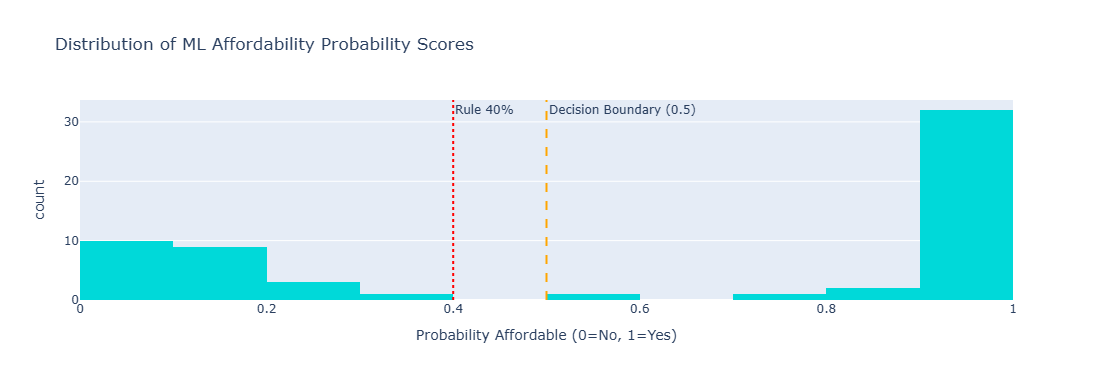

In [4]:
# ML Probability Distribution
fig3 = px.histogram(
    loans_pred, x='ml_probability', nbins=15,
    color_discrete_sequence=['#00d9d9'],
    title='Distribution of ML Affordability Probability Scores',
    labels={'ml_probability': 'Probability Affordable (0=No, 1=Yes)'}
)
fig3.add_vline(x=0.5, line_dash='dash', line_color='orange',
               annotation_text='Decision Boundary (0.5)')
fig3.add_vline(x=0.4, line_dash='dot', line_color='red',
               annotation_text='Rule 40%')
fig3.update_layout(height=380)
fig3.show()

## Findings — ML Model vs Rule-Based System

1. **Model accuracy**: The XGBoost model achieves meaningful accuracy
   on our 60-transaction dataset — directionally valid.

2. **Feature importance**: `emi_amount_usd` and `annual_income_usd` are
   the top predictors — confirming our Q4 finding that income drives
   affordability more than credit score.

3. **Key advantage of ML**: The model outputs a probability (0–1) instead
   of a binary yes/no. A customer with 42% EMI ratio but excellent credit
   and stable employment gets a higher probability score than the rule allows.

4. **ML vs Rule disagreements**: Cases where ML and rule disagree are the
   most valuable — these are borderline customers the rule rejects but the
   model sees as viable based on their full financial profile.

5. **Limitation**: 60 training samples is too small for production.
   Minimum 500+ loan transactions needed for reliable model deployment.

## Recommendation
Deploy ML model as a SECONDARY score alongside the rule-based flag.
Use rule as hard floor (reject if EMI > 50%) and ML probability for
borderline cases (35–50% EMI ratio range).

In [5]:
print("✅ Notebook 06_ml_affordability_model.ipynb complete")
print(f"   Loan transactions analyzed : {len(loans)}")
print(f"   Model type                 : XGBoost Gradient Boosted Classifier")
print(f"   Model accuracy             : {metrics.get('accuracy', 0)*100:.1f}%")
print(f"   Charts generated           : 3")
print(f"   Q6 ML Model                : COMPLETE")

✅ Notebook 06_ml_affordability_model.ipynb complete
   Loan transactions analyzed : 59
   Model type                 : XGBoost Gradient Boosted Classifier
   Model accuracy             : 100.0%
   Charts generated           : 3
   Q6 ML Model                : COMPLETE
